# Emotions per topic — significance testing

Compares outlet anger scores against the Tagesschau baseline per topic cluster using Mann-Whitney U tests with Benjamini-Hochberg FDR correction.

## 1  Load & merge

Load emotion scores and topic assignments, merge on `row_id`.

In [22]:
import pandas as pd
from pathlib import Path

root = Path.cwd()
if root.name == "04_SentimentAnalysis":
    root = root.parent

df = pd.read_csv(root / "04_SentimentAnalysis/outputs/emotion_fulltext_with_topiclabels.csv")


df = df.rename(columns={"Manual Cluster Label": "topic", "emotion_anger": "anger"})
df["anger"] = pd.to_numeric(df["anger"], errors="coerce")
df = df.dropna(subset=["anger", "topic", "source"])


## 2  Pairwise Mann-Whitney U + BH correction

For each *(topic, outlet)* pair with n ≥ 30 on both sides, run a two-sided Mann-Whitney U test and compute rank-biserial effect size r. Apply BH FDR correction across all valid pairs.

In [23]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np

REFERENCE   = "Tagesschau"
ALT_OUTLETS = [o for o in df["source"].unique() if o != REFERENCE]
MIN_N       = 20

records  = []
excluded = []

for topic in df["topic"].unique():
    df_t    = df[df["topic"] == topic]
    ts_vals = df_t.loc[df_t["source"] == REFERENCE, "anger"].values

    for outlet in ALT_OUTLETS:
        alt_vals = df_t.loc[df_t["source"] == outlet, "anger"].values

        if len(alt_vals) < MIN_N or len(ts_vals) < MIN_N:
            excluded.append({"topic": topic, "outlet": outlet,
                             "n_outlet": len(alt_vals), "n_tagesschau": len(ts_vals),
                             "reason": f"n < {MIN_N}"})
            continue

        U, p_raw = mannwhitneyu(alt_vals, ts_vals, alternative="two-sided")
        n1, n2   = len(alt_vals), len(ts_vals)
        r        = 1 - (2 * U) / (n1 * n2)

        records.append({
            "topic":                topic,
            "outlet":               outlet,
            "n_outlet":             n1,
            "n_tagesschau":         n2,
            "mean_anger_outlet":    float(np.mean(alt_vals)),
            "mean_anger_tagesschau": float(np.mean(ts_vals)),
            "U_statistic":          U,
            "p_raw":                p_raw,
            "effect_size_r":        r,
        })

results = pd.DataFrame(records)

reject, p_adj, _, _ = multipletests(results["p_raw"].values, alpha=0.05, method="fdr_bh")
results["p_adjusted"]  = p_adj
results["significant"] = reject

results = results.sort_values("p_adjusted").reset_index(drop=True)
results


,topic,outlet,n_outlet,n_tagesschau,mean_anger_outlet,mean_anger_tagesschau,U_statistic,p_raw,effect_size_r,p_adjusted,significant
0,Social Policy & Welfare,Tichys_Einblick,260,471,0.869515,0.659799,104809.0,3.112432e-57,-0.711726,2.863438e-55,True
1,German Party Politics,Tichys_Einblick,436,388,0.864916,0.676051,138326.0,6.006017e-56,-0.635368,2.762768e-54,True
2,German Economy & Industry,Tichys_Einblick,222,597,0.841044,0.657513,108932.0,1.270280e-45,-0.643835,3.895526e-44,True
3,"Energy, Climate & Environment",Tichys_Einblick,162,461,0.848386,0.675471,62324.0,7.902185e-37,-0.669050,1.817503e-35,True
4,Miscellaneous,Tichys_Einblick,212,612,0.782626,0.577318,102207.0,7.410364e-36,-0.575518,1.363507e-34,True
...,...,...,...,...,...,...,...,...,...,...,...
87,US & Transatlantic Politics,Antispiegel,52,655,0.737026,0.733886,17746.0,6.137467e-01,-0.042043,6.416443e-01,False
88,Russia (-Ukraine) Diplomacy & Sanctions,RT_de,1089,400,0.612221,0.612843,220570.0,7.064873e-01,-0.012718,7.303014e-01,False
89,Russia (-Ukraine) Diplomacy & Sanctions,Nius,66,400,0.602571,0.612843,13464.0,7.948926e-01,-0.020000,8.125569e-01,False
90,Russia-Ukraine War,Nius,30,299,0.685481,0.682301,4549.0,8.982653e-01,-0.014270,9.081363e-01,False


## 3  Heatmaps

**Heatmap 1** — mean anger per topic × outlet; color scale centered on the outlet macro-mean; cells with n < 30 greyed out; `*`/`**` mark BH-significant pairs.

**Heatmap 2** — rank-biserial r per topic × alternative outlet; diverging scale centered at 0.

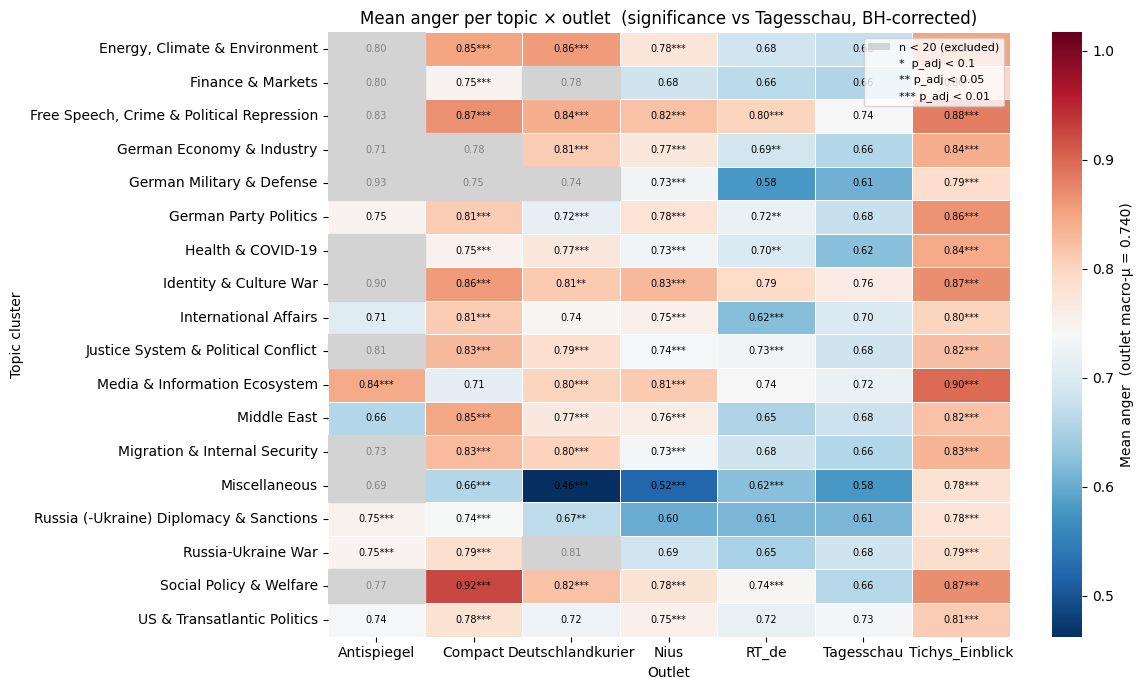

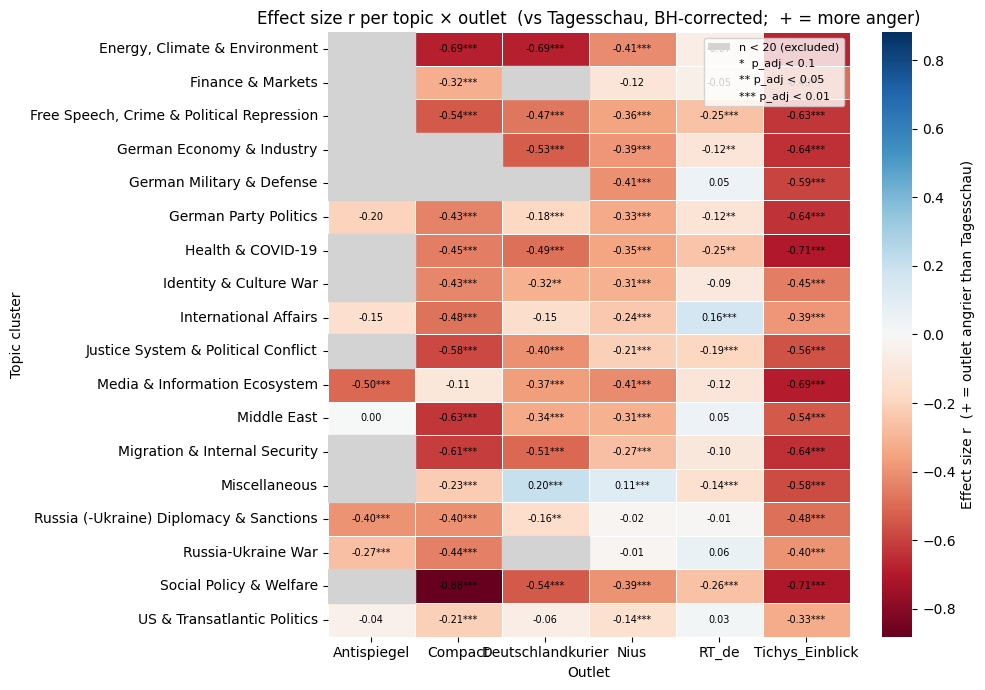

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

ANGER_COL  = "anger"
macro_mean = float(df.groupby("source")[ANGER_COL].mean().mean())

def _sig_marker(p_adj):
    if p_adj < 0.01: return "***"
    if p_adj < 0.05: return "**"
    if p_adj < 0.1: return "*"
    return ""

# ── Build pivots ──────────────────────────────────────────────────────────────
all_outlets = sorted(df["source"].unique())
topics      = sorted(df["topic"].unique())

mean_pivot = (
    df.groupby(["topic", "source"])[ANGER_COL]
    .mean()
    .unstack("source")
    .reindex(index=topics, columns=all_outlets)
)

sig_lookup = (
    results
    .set_index(["topic", "outlet"])["p_adjusted"]
    .to_dict()
)

n_pivot = (
    df.groupby(["topic", "source"])["anger"]
    .count()
    .unstack("source")
    .reindex(index=topics, columns=all_outlets)
    .fillna(0)
)
ts_n = n_pivot.get(REFERENCE, pd.Series(0, index=topics))

grey_mask = pd.DataFrame(False, index=topics, columns=all_outlets)
for col in all_outlets:
    if col == REFERENCE:
        grey_mask[col] = n_pivot[col] < MIN_N
    else:
        grey_mask[col] = (n_pivot[col] < MIN_N) | (ts_n < MIN_N)

vals   = mean_pivot.to_numpy(dtype=float)
spread = max(float(np.nanmax(np.abs(vals - macro_mean))), 1e-6)
vmin, vmax = macro_mean - spread, macro_mean + spread

legend_patches = [
    mpatches.Patch(facecolor="lightgrey", label=f"n < {MIN_N} (excluded)"),
    plt.Line2D([0], [0], color="none", label="*  p_adj < 0.1"),
    plt.Line2D([0], [0], color="none", label="** p_adj < 0.05"),
    plt.Line2D([0], [0], color="none", label="*** p_adj < 0.01"),
]

# ── Heatmap 1: mean anger ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(12, 0.9 * len(all_outlets)),
                                max(7,  0.38 * len(topics))))

sns.heatmap(mean_pivot, ax=ax, annot=False,
            cmap="RdBu_r", center=macro_mean, vmin=vmin, vmax=vmax,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": f"Mean anger  (outlet macro-μ = {macro_mean:.3f})"})

for ri, topic in enumerate(topics):
    for ci, outlet in enumerate(all_outlets):
        val    = mean_pivot.at[topic, outlet]
        marker = _sig_marker(sig_lookup.get((topic, outlet), 1.0)) if outlet != REFERENCE else ""
        if grey_mask.at[topic, outlet]:
            ax.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
            if not np.isnan(val):
                ax.text(ci+0.5, ri+0.5, f"{val:.2f}", ha="center", va="center",
                        fontsize=7, color="grey", zorder=3)
        else:
            ax.text(ci+0.5, ri+0.5, f"{val:.2f}{marker}" if not np.isnan(val) else "",
                    ha="center", va="center", fontsize=7, color="black", zorder=3)

ax.legend(handles=legend_patches, loc="upper right", fontsize=8, frameon=True)
ax.set_title("Mean anger per topic × outlet  (significance vs Tagesschau, BH-corrected)")
ax.set_xlabel("Outlet")
ax.set_ylabel("Topic cluster")
plt.tight_layout()
plt.show()

# ── Heatmap 2: effect size r ─────────────────────────────────────────────────
r_pivot  = results.set_index(["topic", "outlet"])["effect_size_r"].unstack("outlet")
r_topics = r_pivot.index.tolist()
r_outlets= r_pivot.columns.tolist()

grey_r = pd.DataFrame(False, index=r_topics, columns=r_outlets)
for rec in excluded:
    t, o = rec["topic"], rec["outlet"]
    if t in grey_r.index and o in grey_r.columns:
        grey_r.at[t, o] = True

r_spread = max(float(np.nanmax(np.abs(r_pivot.to_numpy(dtype=float)))), 1e-6)

fig2, ax2 = plt.subplots(figsize=(max(10, 0.9 * len(r_outlets)),
                                  max(7,  0.38 * len(r_topics))))

sns.heatmap(r_pivot, ax=ax2, annot=False,
            cmap="RdBu", center=0, vmin=-r_spread, vmax=r_spread,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Effect size r  (+ = outlet angrier than Tagesschau)"})

for ri, topic in enumerate(r_topics):
    for ci, outlet in enumerate(r_outlets):
        val    = r_pivot.at[topic, outlet] if topic in r_pivot.index else float("nan")
        marker = _sig_marker(sig_lookup.get((topic, outlet), 1.0))
        grey   = grey_r.at[topic, outlet] if topic in grey_r.index else True
        if grey:
            ax2.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
            if not np.isnan(val):
                ax2.text(ci+0.5, ri+0.5, f"{val:.2f}", ha="center", va="center",
                         fontsize=7, color="grey", zorder=3)
        else:
            ax2.text(ci+0.5, ri+0.5, f"{val:.2f}{marker}" if not np.isnan(val) else "",
                     ha="center", va="center", fontsize=7, color="black", zorder=3)

ax2.legend(handles=legend_patches, loc="upper right", fontsize=8, frameon=True)
ax2.set_title("Effect size r per topic × outlet  (vs Tagesschau, BH-corrected;  + = more anger)")
ax2.set_xlabel("Outlet")
ax2.set_ylabel("Topic cluster")
plt.tight_layout()
plt.show()


## 4  Miscellaneous cluster — mean anger per topic vs macro mean

Mean anger for every **Manual Topic Label** inside the *Miscellaneous* cluster, sorted descending, with the outlet macro-mean shown as reference.

In [25]:
CLUSTER = "Miscellaneous"

misc = df[df["topic"] == CLUSTER].copy()

topic_stats = (
    misc.groupby("Manual Topic Label")["anger"]
    .agg(mean_anger="mean", n="count")
    .sort_values("mean_anger", ascending=False)
    .reset_index()
)

topic_stats["delta_vs_macro"] = topic_stats["mean_anger"] - macro_mean

print(f"Outlet macro-mean anger : {macro_mean:.4f}\n")
print(topic_stats.to_string(index=False))


Outlet macro-mean anger : 0.7397

         Manual Topic Label  mean_anger   n  delta_vs_macro
          Books and Authors    0.737865 175       -0.001836
       Food and Agriculture    0.693181 188       -0.046520
      Christianity Religion    0.691699 151       -0.048002
   Natural Disasters Storms    0.671018 139       -0.068683
Film Entertainment Industry    0.650958 117       -0.088743
          Art Theft Museums    0.634711 115       -0.104990
    Crans Montana Nightclub    0.617649 149       -0.122052
           Animals Wildlife    0.606290  83       -0.133411
              Miscellaneous    0.596514 308       -0.143188
Celebrity Deaths Obituaries    0.373219 107       -0.366482
      Radio Format Metadata    0.312126 216       -0.427575


### Heatmap: mean anger per topic × outlet  (Miscellaneous cluster)

Topics sorted by descending overall mean anger. Color scale diverges from the outlet macro-mean. Cells with n < 30 are greyed out.

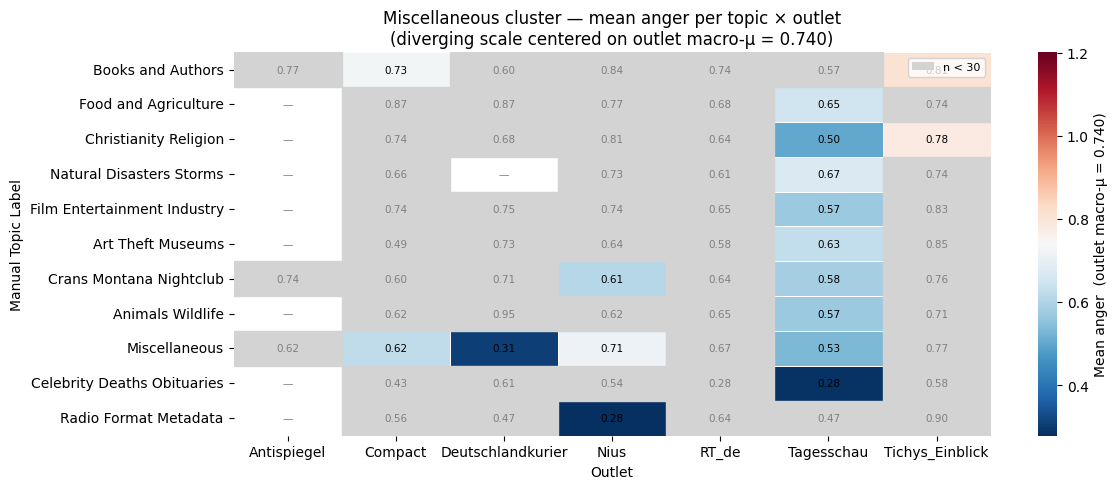

In [26]:
CLUSTER = "Miscellaneous"

misc = df[df["topic"] == CLUSTER].copy()

all_outlets = sorted(df["source"].unique())
misc_topics = (
    misc.groupby("Manual Topic Label")["anger"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

pivot = (
    misc.groupby(["Manual Topic Label", "source"])["anger"]
    .mean()
    .unstack("source")
    .reindex(index=misc_topics, columns=all_outlets)
)

n_pivot = (
    misc.groupby(["Manual Topic Label", "source"])["anger"]
    .count()
    .unstack("source")
    .reindex(index=misc_topics, columns=all_outlets)
    .fillna(0)
)

vals   = pivot.to_numpy(dtype=float)
spread = max(float(np.nanmax(np.abs(vals - macro_mean))), 1e-6)
vmin, vmax = macro_mean - spread, macro_mean + spread

fig, ax = plt.subplots(figsize=(max(12, 0.9 * len(all_outlets)),
                                max(5,  0.45 * len(misc_topics))))

sns.heatmap(pivot, ax=ax, annot=False,
            cmap="RdBu_r", center=macro_mean, vmin=vmin, vmax=vmax,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": f"Mean anger  (outlet macro-μ = {macro_mean:.3f})"})

for ri, topic in enumerate(misc_topics):
    for ci, outlet in enumerate(all_outlets):
        val = pivot.at[topic, outlet]
        n   = int(n_pivot.at[topic, outlet]) if not np.isnan(n_pivot.at[topic, outlet]) else 0
        if np.isnan(val):
            label, col = "—", "grey"
        elif n < 30:
            label, col = f"{val:.2f}", "grey"
            ax.add_patch(plt.Rectangle((ci, ri), 1, 1, color="lightgrey", zorder=2))
        else:
            label, col = f"{val:.2f}", "black"
        ax.text(ci + 0.5, ri + 0.5, label, ha="center", va="center",
                fontsize=7.5, color=col, zorder=3)

import matplotlib.patches as mpatches
ax.legend(
    handles=[mpatches.Patch(facecolor="lightgrey", label="n < 30")],
    loc="upper right", fontsize=8, frameon=True,
)
ax.set_title(
    f"Miscellaneous cluster — mean anger per topic × outlet\n"
    f"(diverging scale centered on outlet macro-μ = {macro_mean:.3f})"
)
ax.set_xlabel("Outlet")
ax.set_ylabel("Manual Topic Label")
plt.tight_layout()
plt.show()